In [3]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"
import netket as nk
import numpy as np
import netket as nk
import jax
print(jax.devices())
import jax.numpy as jnp
import jax.tree_util as tree
import jax.typing as jt
import matplotlib.pyplot as plt
import optax
import random
import time
from flax import nnx
from flax import linen as nn
from netket.experimental.observable import Renyi2EntanglementEntropy
from functools import partial
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product
from typing import Callable, Sequence
from jax.flatten_util import ravel_pytree
from scipy.optimize import minimize

[CudaDevice(id=0)]


In [4]:
# Hilbert space
from netket.hilbert import Spin
N = 10
N_ancilla = 10

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [5]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [4]:
def renyi2_entropy_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente mediante el *swap trick*
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    # ============================================================
    # 2) CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp(jnp.real(log_s1 + log_s2 - log_o1 - log_o2))
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    # ============================================================
    # 5) JACOBIANOS O_θ = ∂_θ log ψ
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state, mode="real", dense=True)
    
    R_exp = R.reshape(-1, 1)  # (n_samples, 1) para broadcasting
    
    # ============================================================
    # 6) TÉRMINO 1: dependencia explícita de R en θ
    #    ⟨R · ∇log R⟩ = ⟨R · 2(O_s1 + O_s2 - O_o1 - O_o2)⟩
    # ============================================================
    grad_log_R = O_s1 + O_s2 - O_o1 - O_o2  # (n_samples, n_params)
    term1 = 2.0 * jnp.mean(R_exp * grad_log_R, axis=0)  # (n_params,)

    # ============================================================
    # 7) TÉRMINO 2: dependencia de p(x)p(y) en θ 
    #    2⟨(R - ⟨R⟩) · (O_o1 + O_o2)⟩
    #    ∇log p(x)p(y) = 2(O_o1 + O_o2) porque p = |ψ|²
    # ============================================================
    R_centered = (R - R_mean).reshape(-1, 1)
    term2 = 2.0 * jnp.mean(R_centered * (O_o1 + O_o2), axis=0)  # (n_params,)

    # ============================================================
    # 8) ∇S₂ = -(term1 + term2) / ⟨R⟩
    # ============================================================
    grad_S2_flat = -(term1 + term2) / R_mean

    _, unravel = jax.flatten_util.ravel_pytree(vstate.parameters)
    grad_S2 = unravel(grad_S2_flat)

    if debug:
        print(f"⟨R⟩  = {float(R_mean):.6f}")
        print(f"S₂   = {float(S2):.6f}")
        print(f"||term1|| = {jnp.linalg.norm(term1):.6f}  (explícito)")
        print(f"||term2|| = {jnp.linalg.norm(term2):.6f}  (REINFORCE)")
        print(f"|∇S₂| = {jnp.linalg.norm(grad_S2_flat):.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_lambda_integral(vstate, subsystem_sites, n_samples, n_lambda=10, key=0, debug=False):
    """
    Calcula S₂ y ∇S₂ usando el método de la λ-integral
    basado en Drut & Porter (2022)

    S₂ = - ∫₀¹ dλ ⟨ln R⟩_{P_λ}
    ∇S₂ = - ∫₀¹ [ ⟨∇lnR⟩_{P_λ} + λ·Cov_{P_λ}(lnR, ∇lnR) + 2⟨(lnR-⟨lnR⟩)(O_o1+O_o2)⟩_{P_λ} ] dλ
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    key_obj = jax.random.PRNGKey(key)
    lambda_grid = jnp.linspace(0.0, 1.0, n_lambda)

    f_vals = []
    grad_f_vals = []

    for lam in lambda_grid:

        key_obj, subkey = jax.random.split(key_obj)

        # =====================================================
        # 1) MUESTREO
        # =====================================================
        all_samples = (
            vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=500)
            .reshape(-1, vstate.hilbert.size)
        )
        all_samples = jax.random.permutation(subkey, all_samples, axis=0)

        samples1 = all_samples[:n_samples]
        samples2 = all_samples[n_samples:2 * n_samples]

        # =====================================================
        # 2) SWAP CONFIGS
        # =====================================================
        all_sites = jnp.arange(samples1.shape[1])
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)

        swapped1 = jnp.concatenate(
            [samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1
        )
        swapped2 = jnp.concatenate(
            [samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1
        )

        # =====================================================
        # 3) LOG-AMPLITUDES Y RATIO R
        # =====================================================
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)

        log_R = jnp.real(log_s1 + log_s2 - log_o1 - log_o2)

        # =====================================================
        # 4) JACOBIANOS O_θ = ∂_θ log ψ
        # =====================================================
        O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                        model_state=vstate.model_state, mode="real", dense=True)

        # ∇ln R = 2*(O_s1 + O_s2 - O_o1 - O_o2)
        grad_lnR = 2.0 * (O_s1 + O_s2 - O_o1 - O_o2)  # (n_samples, n_params)

        # =====================================================
        # 5) PESOS P_λ ∝ p(x)p(y) R^λ
        # =====================================================
        log_weights = lam * log_R
        log_weights -= jax.nn.logsumexp(log_weights)
        weights = jnp.exp(log_weights)  # (n_samples,)

        w = weights.reshape(-1, 1)  # para broadcasting

        # =====================================================
        # 6) f(λ) = ⟨ln R⟩_λ
        # =====================================================
        f_lam = jnp.sum(weights * log_R)
        f_vals.append(f_lam)

        # =====================================================
        # 7) ⟨∇ln R⟩_λ
        # =====================================================
        mean_grad = jnp.sum(w * grad_lnR, axis=0)  # (n_params,)

        # =====================================================
        # 8) Covarianza: Cov_λ(lnR, ∇lnR)
        #    = ⟨lnR · ∇lnR⟩_λ - ⟨lnR⟩_λ · ⟨∇lnR⟩_λ
        # =====================================================
        lnR_exp = log_R.reshape(-1, 1)
        mean_lnR_grad = jnp.sum(w * lnR_exp * grad_lnR, axis=0)
        cov = mean_lnR_grad - f_lam * mean_grad  # (n_params,)

        # =====================================================
        # 9) TÉRMINO REINFORCE: dependencia de p(x)p(y) en θ
        #    2⟨(lnR - ⟨lnR⟩_λ)(O_o1 + O_o2)⟩_λ
        # =====================================================
        lnR_centered = (log_R - f_lam).reshape(-1, 1)
        grad_log_p = O_o1 + O_o2  # ∇log[p(x)p(y)] / 2, shape (n_samples, n_params)
        reinforce = 2.0 * jnp.sum(w * lnR_centered * grad_log_p, axis=0)  # (n_params,)

        # =====================================================
        # 10) ∇f(λ) = ⟨∇lnR⟩_λ + λ·Cov + REINFORCE
        # =====================================================
        grad_f_flat = mean_grad + lam * cov + reinforce  # (n_params,)
        grad_f_vals.append(grad_f_flat)

        if debug:
            ess = 1.0 / jnp.sum(weights ** 2)
            print(f"λ={float(lam):.3f} | f(λ)={float(f_lam):.6f} | "
                  f"||mean_grad||={jnp.linalg.norm(mean_grad):.4f} | "
                  f"||cov||={jnp.linalg.norm(cov):.4f} | "
                  f"||reinforce||={jnp.linalg.norm(reinforce):.4f} | "
                  f"ESS={float(ess):.1f}")

    # =====================================================
    # 11) INTEGRACIÓN TRAPECIO
    # =====================================================
    f_vals = jnp.array(f_vals)
    dlam = lambda_grid[1] - lambda_grid[0]

    S2 = -(dlam * (0.5 * f_vals[0] + jnp.sum(f_vals[1:-1]) + 0.5 * f_vals[-1]))

    flat_grads = jnp.stack(grad_f_vals)  # (n_lambda, n_params)
    grad_S2_flat = -(dlam * (0.5 * flat_grads[0] + jnp.sum(flat_grads[1:-1], axis=0) + 0.5 * flat_grads[-1]))

    _, unravel = jax.flatten_util.ravel_pytree(vstate.parameters)
    grad_S2 = unravel(grad_S2_flat)

    if debug:
        print(f"\nS₂ = {float(S2):.6f}")
        print(f"||∇S₂|| = {jnp.linalg.norm(grad_S2_flat):.6f}")

    return float(S2), grad_S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def renyi2_grad_exact(vstate, subsystem_sites, isFullSum=False):
    """
    Calcula el gradiente exacto de la entropía de Rényi-2 usando
    diferenciación automática sobre la función que calcula S₂ exactamente.
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
        grad_S2: gradiente exacto (misma estructura que vstate.parameters)
    """
    
    # Definir una función que solo depende de los parámetros
    def S2_func(params):
        # Crear un estado temporal con los parámetros dados
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        S2, _ = renyi2_entropy_exact(vstate_tmp, subsystem_sites)
        return S2
    
    # Usar value_and_grad de JAX para obtener S₂ y su gradiente
    S2, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2, S2_grad

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_fullsum(vstate, subsystem_sites, debug=False):
    """
    Calcula la entropía de Rényi-2 y su gradiente usando la matriz de densidad reducida.
    Compatible con FullSumState.
    
    Args:
        vstate: estado variacional de NetKet (FullSumState)
        subsystem_sites: índices del subsistema A
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2 = -log(Tr(ρ_A^2))
        grad_S2: gradiente respecto a parámetros
    """
    from netket.jax import jacobian
    
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # =======================================
    # 1) OBTENER VECTOR DE ESTADO COMPLETO 
    # =======================================
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    if debug:
        print(f"Sistema total: {N} qubits")
        print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
        print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # ============================
    # 2) REORGANIZAR COMO MATRIZ 
    # ============================
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Convertir {-1,+1} a {0,1}
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Reorganizar: primero A, luego B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir a índices
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir matriz ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # =====================
    # 3) CALCULAR ρ_A Y S₂ 
    # =====================
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    rho_A_squared = rho_A @ rho_A
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    if debug:
        print(f"|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f}")
        print(f"Tr(ρ_A) = {jnp.trace(rho_A).real:.6f}")
        print(f"Tr(ρ_A²) = {purity:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ========================
    # 4) CALCULAR GRADIENTE
    # ========================
    # Calcular jacobianos O = ∂log(ψ)/∂θ para todas las configuraciones
    O_all = jacobian(vstate._apply_fun, vstate.parameters, basis,
                     model_state=vstate.model_state, mode="real", dense=False)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    # 
    # Tr(ρ_A²) = Σ_{i,j,k} ψ[i,k] ψ*[j,k] ψ[j,ℓ] ψ*[i,ℓ]
    #
    # ∂Tr(ρ_A²)/∂θ = 2 Re[Σ_{i,j,k} (∂ψ[i,k]/∂θ) ψ*[j,k] (ρ_A²)[j,i]]
    
    def compute_grad_for_leaf(O_leaf):
        """Calcula el gradiente para una hoja del árbol de parámetros"""
        param_shape = O_leaf.shape[1:]
        grad_accum = jnp.zeros(param_shape, dtype=jnp.complex128)
        
        n_configs = len(basis)
        
        for config_idx in range(n_configs):
            i_A = idx_A[config_idx]
            i_B = idx_B[config_idx]
            
            # ∂ψ[i_A, i_B]/∂θ = ψ[i_A, i_B] * O[config_idx]
            d_psi_dtheta = psi[config_idx] * O_leaf[config_idx]
            
            # Contribución: Σ_j ψ*[j, i_B] * (ρ_A²)[j, i_A]
            # Equivalente a: (ψ_matrix[:, i_B])† @ (ρ_A²)[:, i_A]
            contribution = jnp.conj(psi_matrix[:, i_B]) @ rho_A_squared[:, i_A]
            
            grad_accum = grad_accum + contribution * O_leaf[config_idx]
        
        return 2.0 * grad_accum.real
    
    grad_trace = jax.tree_util.tree_map(compute_grad_for_leaf, O_all)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    grad_S2 = jax.tree_util.tree_map(
        lambda g: -g / purity,
        grad_trace
    )
    
    if debug:
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

In [ ]:
@partial(jax.jit, static_argnames=("apply_fun",))
def _renyi2_loss_and_grad(apply_fun, params, model_state,
                          samples1, samples2, swapped1, swapped2):
    """
    Calcula S2 y grad_S2 usando backprop en vez de jacobianos explícitos.
    Memoria: O(n_params) en vez de O(n_samples × n_params)
    """
    def log_psi(p, s):
        return apply_fun({"params": p, **model_state}, s)

    # S2
    log_o1 = log_psi(params, samples1)
    log_o2 = log_psi(params, samples2)
    log_s1 = log_psi(params, swapped1)
    log_s2 = log_psi(params, swapped2)
    R = jnp.exp(jnp.real(log_s1 + log_s2 - log_o1 - log_o2))
    S2 = -jnp.log(jnp.abs(jnp.mean(R)))

    # Gradiente via backprop
    def loss_fn(p):
        lo1 = log_psi(p, samples1)
        lo2 = log_psi(p, samples2)
        ls1 = log_psi(p, swapped1)
        ls2 = log_psi(p, swapped2)
        R_ = jnp.exp(jnp.real(ls1 + ls2 - lo1 - lo2))
        R_mean = jax.lax.stop_gradient(jnp.mean(R_))
        w = jax.lax.stop_gradient(R_ / R_mean)
        return -2.0 * jnp.mean(w * jnp.real(ls1 + ls2)) \
               +2.0 * jnp.mean(jnp.real(lo1 + lo2))

    grad_S2 = jax.grad(loss_fn)(params)

    return S2, grad_S2



def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestreo (NetKet)
    all_samples = vstate.sample(
        n_samples=2 * n_samples, n_discard_per_chain=1000
    ).reshape(-1, vstate.hilbert.size)

    rng = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(rng, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:]

    # Swap
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)

    # S2 y gradiente via backprop
    S2, grad_S2 = _renyi2_loss_and_grad(
        vstate._apply_fun,
        vstate.parameters,
        vstate.model_state,
        samples1, samples2, swapped1, swapped2
    )

    if debug:
        grad_flat, _ = jax.flatten_util.ravel_pytree(grad_S2)
        print(f"S₂    = {float(S2):.6f}")
        print(f"|∇S₂| = {jnp.linalg.norm(grad_flat):.6f}")

    return S2, grad_S2

def renyi2_entropy_sampled(vstate, partition, n_samples):
    S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples)
    return float(S2)

In [11]:
from functools import partial
from netket.experimental.observable import AbstractObservable

class FreeRenyiEnergyObservable(AbstractObservable):
    def __init__(self, hilbert, H, partition, T):
        super().__init__(hilbert)
        self.H = H
        self.partition = partition
        self.T = T

    @property
    def dtype(self):
        return float


@partial(jax.jit, static_argnames=("logpsi",))
def _free_renyi_grad_jit(logpsi, params, model_state,
                          samples1, samples2, sigma_p, mels,
                          subsystem_sites, complement_sites, T):

    def log_psi(p, s):
        return logpsi({"params": p, **model_state}, s)

    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)

    def loss_fn(p):
        # Energía
        @partial(jax.vmap, in_axes=(0, 0, 0))
        def e_loc_p(sigma, eta, mel):
            return jnp.sum(mel * jnp.exp(log_psi(p, eta) - log_psi(p, sigma)))

        E_loc = e_loc_p(samples1, sigma_p, mels)
        E_mean = jax.lax.stop_gradient(jnp.mean(E_loc))
        loss_E = 2.0 * jnp.mean(
            jax.lax.stop_gradient(E_loc - E_mean) * jnp.real(log_psi(p, samples1))
        )

        # S2
        lo1 = log_psi(p, samples1)
        lo2 = log_psi(p, samples2)
        ls1 = log_psi(p, swapped1)
        ls2 = log_psi(p, swapped2)
        R = jnp.exp(jnp.real(ls1 + ls2 - lo1 - lo2))
        R_mean = jax.lax.stop_gradient(jnp.mean(R))
        w = jax.lax.stop_gradient(R / R_mean)
        loss_S2 = -2.0 * jnp.mean(w * jnp.real(ls1 + ls2)) \
                  + 2.0 * jnp.mean(jnp.real(lo1 + lo2))

        S2 = jax.lax.stop_gradient(-jnp.log(jnp.abs(R_mean)))

        return loss_E - T * loss_S2, (E_mean, S2)

    (_, (E_mean, S2)), grad_F = jax.value_and_grad(loss_fn, has_aux=True)(params)

    return E_mean, S2, grad_F


@nk.vqs.expect_and_grad.dispatch
def expect_and_grad_free_renyi(
    vstate: nk.vqs.MCState, op: FreeRenyiEnergyObservable, chunk_size, **kwargs
):
    subsystem_sites = jnp.array(op.partition, dtype=int)
    all_sites = jnp.arange(vstate.hilbert.size)
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)

    # Muestreo: samples1 del vstate, samples2 independiente
    samples1 = vstate.samples.reshape(-1, vstate.hilbert.size)
    samples2 = vstate.sample(n_samples=vstate.n_samples).reshape(-1, vstate.hilbert.size)
    sigma_p, mels = op.H.get_conn_padded(samples1)

    E_mean, S2, grad_F = _free_renyi_grad_jit(
        vstate._apply_fun,
        vstate.parameters,
        vstate.model_state,
        samples1, samples2, sigma_p, mels,
        subsystem_sites, complement_sites,
        op.T
    )

    F = float(E_mean) - op.T * float(S2)
    F_stats = nk.stats.statistics(jnp.array([[F]]))

    return F_stats, grad_F



In [ ]:
class ARNN_Z2(nn.Module):

    worker: nn.Module
    trivial_Z2: bool = False

    def conditional(self, inputs, index):
        return self.worker.conditional(inputs, index)

    def reorder(self, inputs, axis=-1):
        return self.worker.reorder(inputs, axis=axis)

    def inverse_reorder(self, inputs, axis=-1):
        return self.worker.inverse_reorder(inputs, axis=axis)

    def __call__(self, x):
        output_x = jnp.atleast_1d(self.worker(x))
        output_inv_x = jnp.atleast_1d(self.worker(-x))

        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        if self.trivial_Z2:
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            b = jnp.array([1.0, -1.0])[:, None]
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res

In [ ]:

def free_energy_minimize_SR_SGD(vstate, T, partition, Hamiltonian, n_steps=1000,
                                verbose=True, freq=50, plot=True,
                                learning_rate=None, diag_shift=None,
                                n_samples_sr=4096):
    if learning_rate is None:
        learning_rate = optax.warmup_cosine_decay_schedule(0.1, 0.1, 100, n_steps, 0.001)
    if diag_shift is None:
        diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

    sr = nk.optimizer.SR(diag_shift=diag_shift)
    free_renyi_op = FreeRenyiEnergyObservable(vstate.hilbert, Hamiltonian, partition, T)
    n_samples_full = vstate.n_samples

    free_energy_history = []
    best_F = float('inf')
    best_params = None

    for step in range(n_steps):
        t0 = time.time()

        F_stats, F_grad = vstate.expect_and_grad(free_renyi_op)

        vstate.n_samples = n_samples_sr
        delta = sr(vstate, F_grad, step)
        vstate.n_samples = n_samples_full

        lr = float(learning_rate(step) if callable(learning_rate) else learning_rate)
        vstate.parameters = jax.tree_util.tree_map(
            lambda p, d: p - lr * d, vstate.parameters, delta
        )

        F_val = float(F_stats.mean.real)
        free_energy_history.append(F_val)

        if F_val < best_F:
            best_F = F_val
            best_params = vstate._parameters

        if step % freq == 0 and verbose:
            print(f"Step {step:4d} | F={F_val:.6f} | t={time.time()-t0:.3f}s")

    # Restaurar mejores parámetros y calcular E y S2 finales
    vstate.parameters = best_params

    E_best = float(vstate.expect(Hamiltonian).mean.real)
    S2_best = float(renyi2_entropy_sampled(vstate, partition, n_samples_full))
    best_F = E_best - T * S2_best

    if plot:
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$", color="tab:blue")
        plt.tight_layout()
        plt.show()

    return (free_energy_history, best_F, E_best, S2_best)

Quantum Neural Network training at a given temperature

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}")

Step    0 | F=-17.952493 | t=6.136s
Step   20 | F=-30.679692 | t=0.215s
Step   40 | F=-32.944290 | t=0.203s
Step   60 | F=-33.636608 | t=0.200s
Step   80 | F=-32.291405 | t=0.199s
Step  100 | F=-29.708741 | t=0.218s
Step  120 | F=-32.831382 | t=0.204s
Step  140 | F=-33.553337 | t=0.202s
Step  160 | F=-33.157776 | t=0.215s
Step  180 | F=-32.252188 | t=0.189s
Step  200 | F=-33.525554 | t=0.212s
Step  220 | F=-34.016491 | t=0.224s
Step  240 | F=-33.313366 | t=0.227s
Step  260 | F=-32.730791 | t=0.230s
Step  280 | F=-34.822551 | t=0.237s


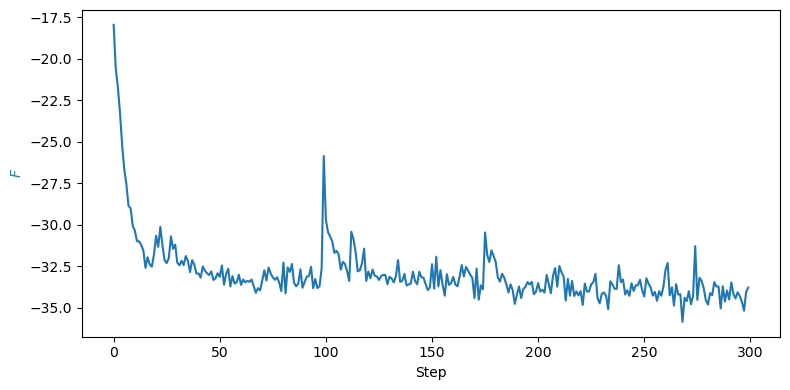

Best solution: S₂=6.022805, E=-4.749254, F=-34.863280


In [33]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)

arnn = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
model = ARNN_Z2(worker=arnn, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960)
T = 5

n_steps = 300
lr = optax.warmup_cosine_decay_schedule(0.02, 0.02, 100, n_steps, 0.001)
# lr = optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr, diag_shift=diag_shift, freq=20)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [ ]:
#Minimizar F = <H> - TS₂ en función de T con scipy
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    # vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}, {result["result"].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

Temperaturas:   0%|          | 0/40 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | F=-15.004815 | t=0.133s
Step   50 | F=-16.722431 | t=0.132s
Step  100 | F=-16.722592 | t=0.131s
Step  150 | F=-16.722380 | t=0.130s
Step  200 | F=-16.722557 | t=0.131s
Step  250 | F=-16.722521 | t=0.128s


Temperaturas:   2%|▎         | 1/40 [00:39<25:33, 39.33s/it]

  Mejor resultado: E=-16.7225, S₂=0.0000, F=-16.7225

=== Temperatura T = 0.385 ===
Step    0 | F=-16.722621 | t=0.129s
Step   50 | F=-16.722185 | t=0.128s
Step  100 | F=-16.721865 | t=0.130s
Step  150 | F=-16.722001 | t=0.127s
Step  200 | F=-16.722133 | t=0.131s
Step  250 | F=-16.722232 | t=0.136s


Temperaturas:   5%|▌         | 2/40 [01:18<24:50, 39.22s/it]

...

  Mejor resultado: E=-0.1357, S₂=6.5095, F=-92.7706

=== Temperatura T = 14.615 ===
Step    0 | F=-95.525378 | t=0.132s
Step   50 | F=-46.661396 | t=0.136s
Step  100 | F=-47.808911 | t=0.135s
Step  150 | F=-59.579816 | t=0.138s
Step  200 | F=-79.880401 | t=0.137s
Step  250 | F=-90.263157 | t=0.138s


Temperaturas:  98%|█████████▊| 39/40 [27:30<00:41, 41.29s/it]

  Mejor resultado: E=-0.3715, S₂=6.6885, F=-98.1269

=== Temperatura T = 15.000 ===
Step    0 | F=-103.956395 | t=0.131s
Step   50 | F=-46.858433 | t=0.136s
Step  100 | F=-50.300518 | t=0.137s
Step  150 | F=-58.312787 | t=0.136s
Step  200 | F=-72.925364 | t=0.138s
Step  250 | F=-91.037162 | t=0.136s


Temperaturas: 100%|██████████| 40/40 [28:10<00:00, 42.27s/it]

  Mejor resultado: E=1.4917, S₂=2.9509, F=-42.7711


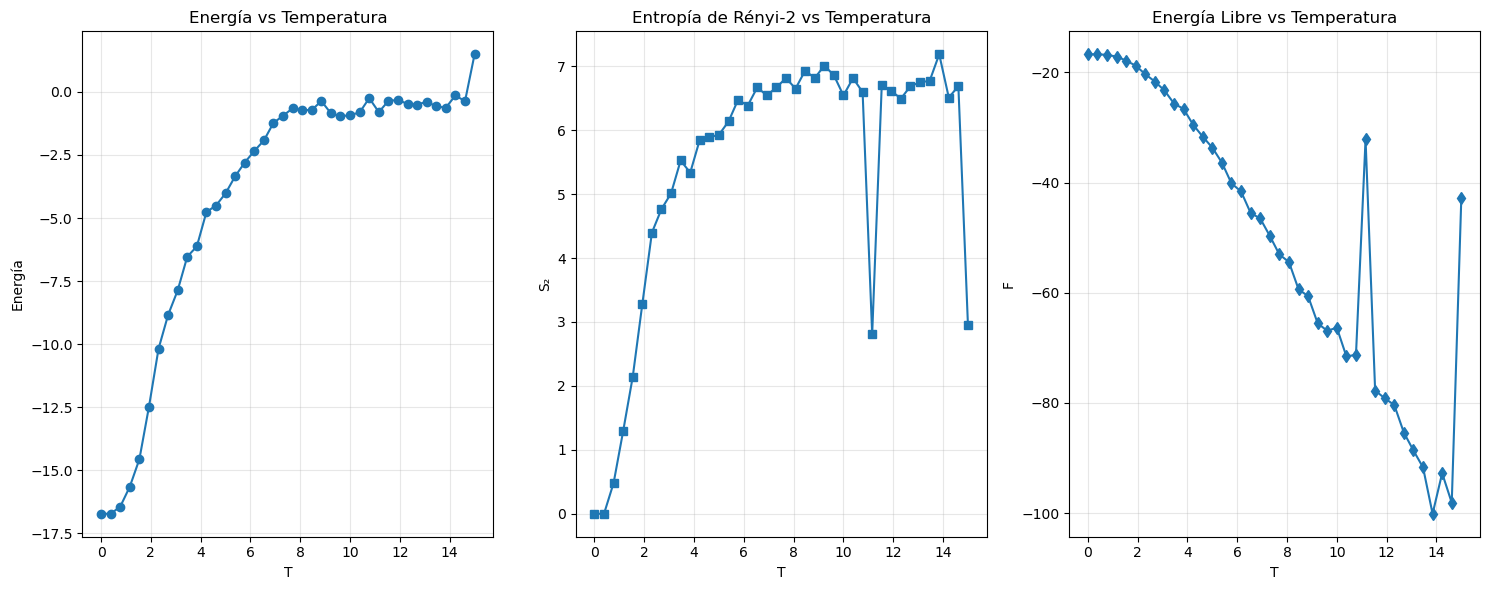

True

In [126]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=None)

T_array = np.linspace(0, 15, 40)
n_steps = 300

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate.init_parameters()
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate=optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
        n_samples_sr=4096
    )
    best_params = vstate.parameters

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 6))

plt.subplot(1, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

enviar_grafica_telegram()

In [127]:
import json
import os

os.makedirs("data", exist_ok=True)

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

# Guardar en data/
with open(f"data/results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("output.png", dpi=200, bbox_inches="tight")
enviar_grafica_telegram()
plt.show()